In [1]:
import pickle
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def filter_score(smiles, cache_dict, length):
    values = cache_dict.get(smiles)
    if values:
        if values[0] == -10000.0:
            return [float("nan")]*length
        else:
            return values
    else:
        return [float("nan")]*length

def extract_score(target_file, cache_dict, target_columns, scaler_dict, target_objective):
    with open(target_file, "r") as g:
        data = g.readlines()
    smiles_list = [line.split(", ")[1] for line in data]
    predicted_fitness = [float(line.strip().split(", ")[2]) for line in data]
    scores = [filter_score(smiles, cache_dict, len(target_columns)) for smiles in smiles_list]
    df = pd.DataFrame(scores, columns=target_columns)
    df["predicted_fitness"] = predicted_fitness
    scaler_score_list = []
    for i, row in df.iterrows():
        score = 0
        for target in df.columns:
            if target == "predicted_fitness":
                break
            mean, std = scaler_dict[target]
            if target_objective[target] == "minimize":
                score += (row[target] - mean) / std * (-1)
            else:
                score += (row[target] - mean) / std
        scaler_score_list.append(score)
    df['scaler score'] = scaler_score_list
    return df

def extract_benchmark_dict(sub_dir_name, parent_dir, cache_dict, target_columns, scaler_dict, target_objective, score_columns, num_fold):
    benchmark_dict = {}
    for sub_dir in sub_dir_name:
        real_dir = os.path.join(parent_dir, sub_dir)
        sub_data = pd.DataFrame()
        for fold in range(1, num_fold+1):
            target_file = os.path.join(real_dir+"_{}".format(fold), "generation_all_best.txt")
            df = extract_score(target_file, cache_dict, target_columns, scaler_dict, target_objective)
            rename_dict = {score: score+"_{}".format(fold) for score in score_columns}
            df = df.rename(columns=rename_dict)
            sub_data = pd.concat([sub_data, df], axis=1)
        benchmark_dict.update({sub_dir: sub_data})
    return benchmark_dict

def process_lines(data, target_columns):
    means = data[target_columns].mean(axis=1)
    stds = data[target_columns].std(axis=1)
    return means, stds

def create_scaler_scores(benchmark_dict, sub_dir_name, save_dir, num_fold, num_generation, color_dict,
                         alpha_span = 0.25, center_linewidth = 0.75, label_fontsize = 12, legend_fontsize = 9):
    # plot scaler scores
    scaler_columns = ["scaler score_{}".format(fold) for fold in range(1, num_fold+1)]
    x = [i for i in range(1, num_generation+1)]

    plt.figure(dpi=100)
    for sub_dir in sub_dir_name:
        data = benchmark_dict[sub_dir]
        if sub_dir == "janus_scaler":
            pred_fitness_columns = ["predicted_fitness_{}".format(fold) for fold in range(1, num_fold+1)]
            means, stds = process_lines(data, pred_fitness_columns)
            plt.plot(x, means, color=color_dict["predicted_fitness"], label=sub_dir+" (surrogate)", linewidth=center_linewidth*2)
            positive = means + stds * 1.96 / np.sqrt(num_fold)
            negative = means - stds * 1.96 / np.sqrt(num_fold)
            plt.plot(x, positive, color=color_dict["predicted_fitness"], alpha=alpha_span, linewidth=0.1)
            plt.plot(x, negative, color=color_dict["predicted_fitness"], alpha=alpha_span, linewidth=0.1)
            plt.fill_between(x,positive,negative, color=color_dict["predicted_fitness"], alpha=alpha_span)

        means, stds = process_lines(data, scaler_columns)
        plt.plot(x, means, color=color_dict[sub_dir], label=sub_dir+" (actual)", linewidth=center_linewidth*2)
        positive = means + stds * 1.96 / np.sqrt(num_fold)
        negative = means - stds * 1.96 / np.sqrt(num_fold)
        plt.plot(x, positive, color=color_dict[sub_dir], alpha=alpha_span, linewidth=0.1)
        plt.plot(x, negative, color=color_dict[sub_dir], alpha=alpha_span, linewidth=0.1)
        plt.fill_between(x,positive,negative, color=color_dict[sub_dir], alpha=alpha_span)
        plt.grid(color = 'gray', linestyle = '-', linewidth = 0.25)

    plt.title("Scaler Scores",fontsize=label_fontsize)
    plt.legend(fontsize=legend_fontsize)
    plt.xlabel("Generation", fontsize=label_fontsize)
    plt.ylabel("Normalized scores", fontsize=label_fontsize)
    plt.savefig(os.path.join(save_dir, "total_scaler_scores"+".svg"), format='svg')


def create_separate_plot(benchmark_dict, sub_dir_name, target_columns, scaler_dict, save_dir, num_fold, num_generation, color_dict, marker_dict,
                         alpha_span = 0.25, center_linewidth = 0.75, label_fontsize = 12, legend_fontsize = 9 ,normalize_score=False):
    # plot individual scores
    def normalize(x, mu, std):
        return (x - mu) / std
    x = [i for i in range(1, num_generation+1)]
    plt.figure(dpi=100)
    for target in target_columns:
        scaler_columns = [target + "_{}".format(fold) for fold in range(1, num_fold+1)]
        for sub_dir in sub_dir_name:
            data = benchmark_dict[sub_dir]
            means, stds = process_lines(data, scaler_columns)
            positive = means + stds * 1.96 / np.sqrt(num_fold)
            negative = means - stds * 1.96 / np.sqrt(num_fold)
            if normalize_score:
                mu, std = scaler_dict[target]
                means = normalize(means, mu, std)
                positive = normalize(positive, mu, std)
                negative = normalize(negative, mu, std)
            plt.plot(x, means, color=color_dict[sub_dir], label=target+", "+sub_dir, marker=marker_dict[target], linewidth=center_linewidth)
            plt.plot(x, positive, color=color_dict[sub_dir], alpha=alpha_span, linewidth=0.01)
            plt.plot(x, negative, color=color_dict[sub_dir], alpha=alpha_span, linewidth=0.01)
            plt.fill_between(x,positive,negative, color=color_dict[sub_dir], alpha=alpha_span)
            plt.grid(color = 'gray', linestyle = '-', linewidth = 0.25)

    plt.title("Individual Scores", fontsize=label_fontsize)
    plt.legend(fontsize=legend_fontsize, loc="upper left")
    plt.xlabel("Generation", fontsize=label_fontsize)
    plt.ylabel("Scores", fontsize=label_fontsize)
    plt.savefig(os.path.join(save_dir, "separate_scores"+".svg"), format='svg')


""" Cutoff-based"""

def binary_conversion(value, cutoff, objective):
    if objective == "maximize":
        if value >= cutoff:
            return 1
        else:
            return 0
    elif objective == "minimize":
        if value <= cutoff:
            return 1
        else:
            return 0

def statistics_cutoffs(data, cutoff_dict, target_objective, target_columns, num_fold):
    pass_cutoff_num = [0]*(len(target_columns)+1) # np.zeros(len(target_columns)+1)
    for fold in range(1, num_fold+1):
        subdata = data[[t+"_{}".format(fold) for t in target_columns]]
        sub_num = np.zeros(len(subdata))
        for target in target_columns:
            sub_target = target+"_{}".format(fold)
            binary_df = subdata[[sub_target]].astype(float).applymap(lambda x: binary_conversion(x, cutoff_dict[target], target_objective[target]))
            sub_num += binary_df.values.reshape(1,-1)[0]
        for x in sub_num:
            pass_cutoff_num[int(x)] += 1
    return pass_cutoff_num

def create_cutoff_plot(benchmark_dict, sub_dir_name, target_columns, target_objective, cutoff_dict, num_fold, save_dir, color_dict,
                       bar_width = 0.35):
    plt.figure(dpi=100)
    x = np.arange(len(target_columns)+1)
    for i, sub_dir in enumerate(sub_dir_name):
        data = benchmark_dict[sub_dir]
        heights = statistics_cutoffs(data, cutoff_dict, target_objective, target_columns, num_fold)
        plt.bar(x+ bar_width*i, heights, width=bar_width, label=sub_dir, color=color_dict[sub_dir])

    plt.legend()
    plt.ylabel("Relative fraction")
    plt.xlabel("Number of objectives passing the thresholds")
    plt.xticks(x + bar_width/2, [str(z) for z in range(0, len(target_columns)+1)])
    plt.savefig(os.path.join(save_dir, "cutoff_objectives"+".svg"), format='svg')


In [2]:
data_path = "./RESULTS/docking/cal_results.csv"
target_columns = ["1syh score", "4lde score", "6y2f score"]
score_columns = ["1syh score", "4lde score", "6y2f score", "scaler score", "predicted_fitness"]
scaler_dict = {"1syh score": (-2.832, 8.928), "4lde score": (-7.547, 1.617), "6y2f score": (-5.528, 0.997)}
cutoff_dict = {"1syh score": -7.7, "4lde score": -9.3, "6y2f score": -6.8}
target_objective = {"1syh score":"minimize", 
                    "4lde score":"minimize", 
                    "6y2f score":"minimize"}
num_fold = 1
data = pd.read_csv(data_path)
data = data.rename(columns={"1syh score":"1syh score_1", "4lde score":"4lde score_1", "6y2f score":"6y2f score_1"})
# data
statistics_cutoffs(data, cutoff_dict, target_objective, target_columns, num_fold)

[820, 3626, 4802, 1221]

## Docking

In [3]:
dataset = "docking"

""" Dataset setting """
parent_dir = "RESULTS/{}".format(dataset)
sub_dir_name = ["janus_scaler", "janus_uncertainty"]#, "janus_uncertainty_tight"]
target_columns = ["1syh score", "4lde score", "6y2f score"]
score_columns = ["1syh score", "4lde score", "6y2f score", "scaler score", "predicted_fitness"]
scaler_dict = {"1syh score": (-2.832, 8.928), "4lde score": (-7.547, 1.617), "6y2f score": (-5.528, 0.997)}
cutoff_dict = {"1syh score": -7.7, "4lde score": -9.3, "6y2f score": -6.8}
target_objective = {"1syh score":"minimize", 
                    "4lde score":"minimize", 
                    "6y2f score":"minimize"}
save_dir = "figures/plot_iteration/{}".format(dataset)
os.makedirs(save_dir, exist_ok=True)
num_fold = 15
num_generation = 10

with open(os.path.join(parent_dir, "cal_dict.pkl"), "rb") as f:
    cache_dict = pickle.load(f)
benchmark_dict = extract_benchmark_dict(sub_dir_name, parent_dir, cache_dict, target_columns, scaler_dict, target_objective, score_columns, num_fold)

""" Plot setting """
color_dict = {"janus_scaler":"red", "janus_uncertainty": "green", "janus_uncertainty_tight": "blue", "predicted_fitness":"orange"}
marker_dict = {"1syh score": "*", "4lde score": "s", "6y2f score":"x"}

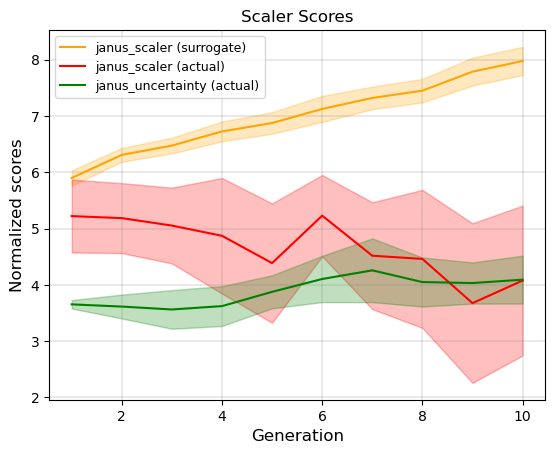

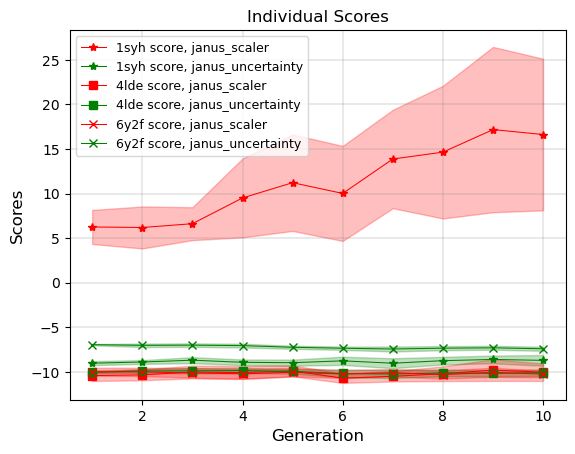

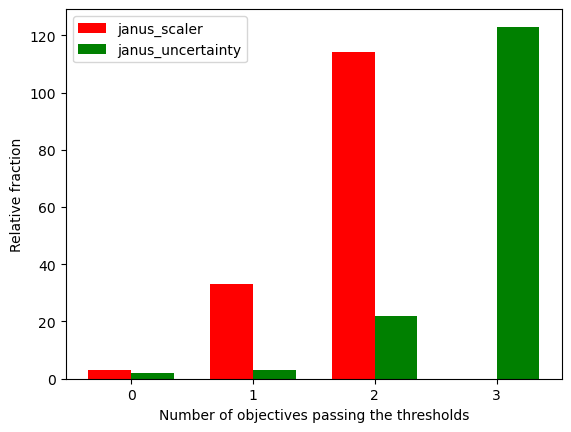

In [5]:
create_scaler_scores(benchmark_dict, sub_dir_name, save_dir, num_fold, num_generation, color_dict)
create_separate_plot(benchmark_dict, sub_dir_name, target_columns, scaler_dict, save_dir, num_fold, num_generation, color_dict, marker_dict)
create_cutoff_plot(benchmark_dict, sub_dir_name, target_columns, target_objective, cutoff_dict, num_fold, save_dir, color_dict)

## Organic Emitter

In [2]:
dataset = "organic_emitter"
""" Dataset setting """
parent_dir = "RESULTS/{}".format(dataset)
sub_dir_name = ["janus_scaler", "janus_uncertainty"]#, "janus_uncertainty_tight"]
target_columns = ["singlet-triplet value", "oscillator strength", "multi-objective value"]
score_columns = ["singlet-triplet value", "oscillator strength", "multi-objective value", "scaler score", "predicted_fitness"]
scaler_dict = {"singlet-triplet value": (1.003, 0.396), "oscillator strength": (0.086, 0.149), "multi-objective value": (-1.6, 0.65),}
cutoff_dict = {"singlet-triplet value":-0.4886, "oscillator strength":0.373, "multi-objective value": -0.679}
target_objective = {"singlet-triplet value":"maximize", 
                    "oscillator strength":"maximize", 
                    "multi-objective value":"maximize"} # The singlet-triplet value is maximization because the scores has been multiplied -1
save_dir = "figures/plot_iteration/{}".format(dataset)
os.makedirs(save_dir, exist_ok=True)
num_fold = 15
num_generation = 10

with open(os.path.join(parent_dir, "cal_dict.pkl"), "rb") as f:
    cache_dict = pickle.load(f)
benchmark_dict = extract_benchmark_dict(sub_dir_name, parent_dir, cache_dict, target_columns, scaler_dict, target_objective, score_columns, num_fold)

""" Plot setting """
color_dict = {"janus_scaler":"red", "janus_uncertainty": "green", "janus_uncertainty_tight": "blue", "predicted_fitness":"orange"}
marker_dict = {"singlet-triplet value": "*", "oscillator strength": "s", "multi-objective value":"x"}

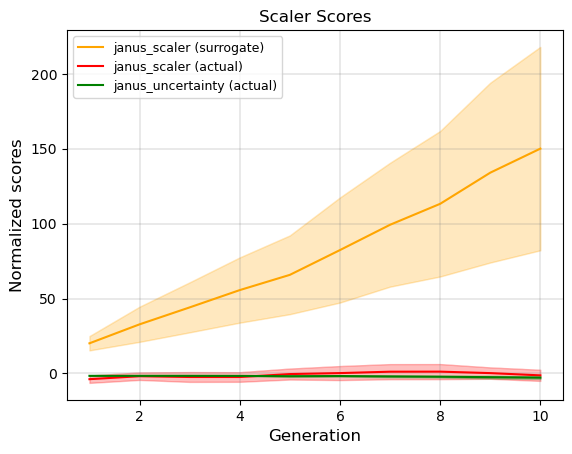

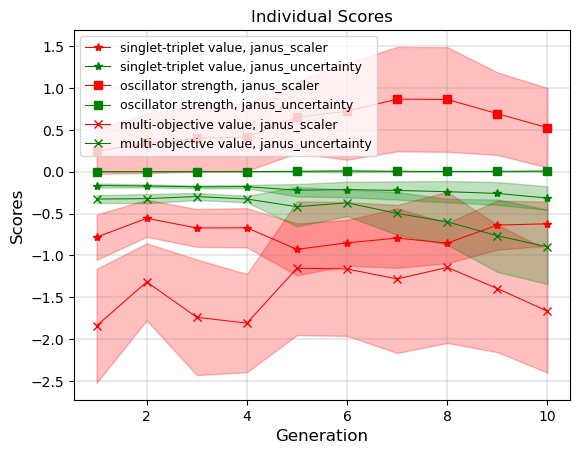

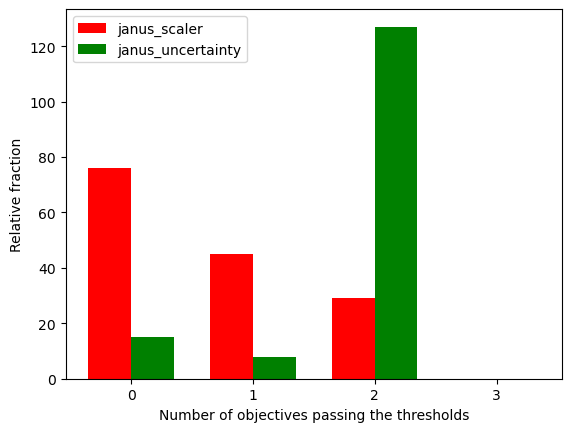

In [3]:
create_scaler_scores(benchmark_dict, sub_dir_name, save_dir, num_fold, num_generation, color_dict)
create_separate_plot(benchmark_dict, sub_dir_name, target_columns, scaler_dict, save_dir, num_fold, num_generation, color_dict, marker_dict)
create_cutoff_plot(benchmark_dict, sub_dir_name, target_columns, target_objective, cutoff_dict, num_fold, save_dir, color_dict)

In [21]:
data_path = "./RESULTS/organic_emitter/cal_results.csv"
target_columns = ["singlet-triplet value", "oscillator strength", "multi-objective value"]
cutoff_dict = {"singlet-triplet value":-0.4886, "oscillator strength":0.373, "multi-objective value": -0.679}
target_objective = {"singlet-triplet value":"maximize", 
                    "oscillator strength":"maximize", 
                    "multi-objective value":"maximize"}
num_fold = 1
data = pd.read_csv(data_path)
data = data.rename(columns={"singlet-triplet value":"singlet-triplet value_1", "oscillator strength":"oscillator strength_1", "multi-objective value":"multi-objective value_1"})
statistics_cutoffs(data, cutoff_dict, target_objective, target_columns, num_fold)
data[(data["singlet-triplet value_1"] >= -0.4896) & (data["oscillator strength_1"] >=0.373) & (data["multi-objective value_1"] >=-0.679)]
smiles = "CC1OC2CC13CC1(CC31)C2CP"

,smiles,singlet-triplet value_1,oscillator strength_1,multi-objective value_1
11986,CC1OC2CC13CC1(CC31)C2CP,-0.160247,0.429332,-0.094172


## HCE simple

In [6]:
dataset = "hce_simple"

""" Dataset setting """
parent_dir = "RESULTS/{}".format(dataset)
sub_dir_name = [ "janus_scaler", "janus_uncertainty"]#, "janus_uncertainty_tight"]
target_columns = ["dipm", "gap", "lumo", "combined"] # ["gap", "lumo", "dipm", "combined"]
score_columns = ["dipm", "gap", "lumo", "combined", "scaler score", "predicted_fitness"]
scaler_dict = {"gap": (1.497, 0.456), "lumo": (-8.032, 0.426), "dipm": (2.819, 1.652), "combined":(11.824, 1.685)}
cutoff_dict = {"gap": 2.0625, "lumo": -8.6077, "dipm": 5.019, "combined":14.0568}
target_objective = {"gap": "maximize", "lumo": "minimize", "dipm": "maximize", "combined": "maximize"}
save_dir = "figures/plot_iteration/{}".format(dataset)
os.makedirs(save_dir, exist_ok=True)
num_fold = 10
num_generation = 10

with open(os.path.join(parent_dir, "cal_dict.pkl"), "rb") as f:
    cache_dict = pickle.load(f)
benchmark_dict = extract_benchmark_dict(sub_dir_name, parent_dir, cache_dict, target_columns, scaler_dict, target_objective, score_columns, num_fold)

""" Plot setting """
color_dict = {"janus_scaler":"red", "janus_uncertainty": "green", "janus_uncertainty_tight": "blue", "predicted_fitness":"orange"}
marker_dict = {"gap": "*", "lumo": "s", "dipm":"x", "combined":"o"}

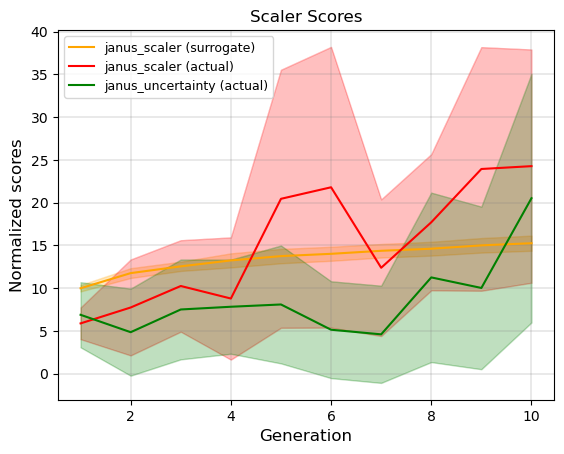

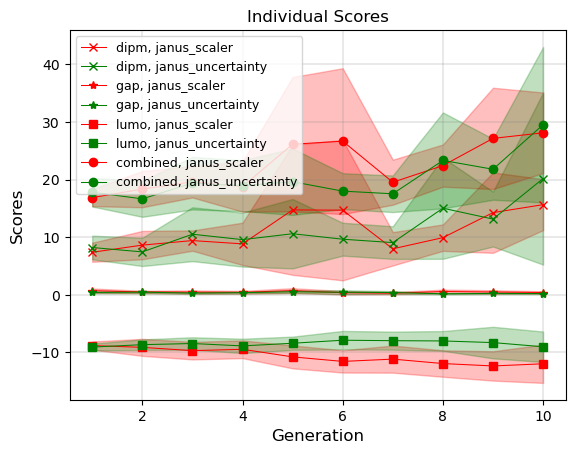

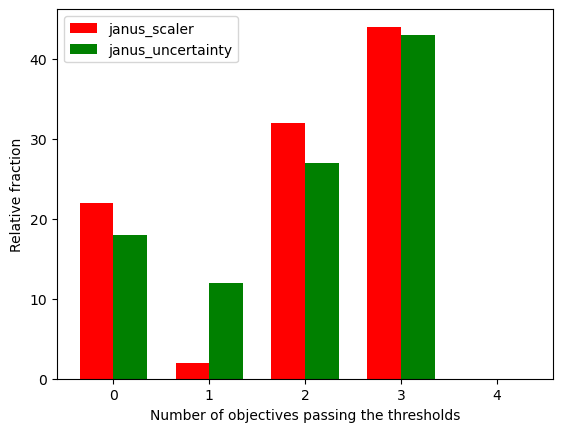

In [7]:
create_scaler_scores(benchmark_dict, sub_dir_name, save_dir, num_fold, num_generation, color_dict)
create_separate_plot(benchmark_dict, sub_dir_name, target_columns, scaler_dict, save_dir, num_fold, num_generation, color_dict, marker_dict)
create_cutoff_plot(benchmark_dict, sub_dir_name, target_columns, target_objective, cutoff_dict, num_fold, save_dir, color_dict)

In [10]:
data_path = "./RESULTS/hce_simple/cal_results.csv"
target_columns = ["dipm", "gap", "lumo", "combined"] # ["gap", "lumo", "dipm", "combined"]

cutoff_dict = {"gap": 2.0625, "lumo": -8.6077, "dipm": 5.019, "combined":14.0568}
target_objective = {"gap": "maximize", "lumo": "minimize", "dipm": "maximize", "combined": "maximize"}

num_fold = 1
data = pd.read_csv(data_path)
data = data.rename(columns={"gap":"gap_1", "lumo":"lumo_1", "dipm":"dipm_1", "combined":"combined_1"})
print(statistics_cutoffs(data, cutoff_dict, target_objective, target_columns, num_fold))
# data[(data["gap_1"] >= 2.0625) & (data["lumo_1"] <=-8.6077) ]#& (data["dipm_1"] >=5.019)]
data[(data["lumo_1"] <=-8.6077) & (data["dipm_1"] >=5.019) & (data["combined_1"] >=14.0568)]
# data[(data["gap_1"] >= 2.0625)]

[29, 23, 141, 160, 0]


,smiles,dipm_1,gap_1,lumo_1,combined_1
1,c1cc2c(cnsnn1)c1cnc3cc(-c4nccc5nsnc45)[se]c3c1...,7.228,0.872149,-8.9096,17.124149
7,CC(C[Se]C1N=CC=C2C=CN=C2CC1=CN=CCC=CS#CCC(Cc1n...,6.721,0.732427,-8.8134,16.381227
8,C=NNC=c1c(=CCc2cc3cnc4cc(-c5ncncn5)ncc4c3c3c[n...,10.101,0.439381,-8.6530,19.307781
11,[C+](C=NSc1ncncn1)CN=Cc1cc2ncc3cc(Cc4cnsn4)c4c...,6.282,0.491297,-12.3751,19.262797
13,CNC=c1c2cc3ncc2cc2cc[se]c2c[se]c(-c2nccc4nsnc2...,6.872,0.163731,-8.7673,15.917431
...,...,...,...,...,...
341,CCC1(CN=[SH]#[N+]c2ncncn2)CC=CNNSC(C)CN=CN=CN=...,30.902,0.090127,-13.2579,44.364427
342,C=c1c2c[se]c1=CCc1cc3cnc4c(c(-c5ncncn5)ncc4c3c...,6.832,0.006741,-8.7172,15.670341
346,CSC#[S+][SH]=C(CN=CC=CCC=NC=NC1=c2c(c(C)nccc3c...,8.041,1.516963,-10.8644,19.905400
348,C=C(C=c1c(=C)[nH]c2cccnc12)C1=NSN(C)c2cc3nsnc3...,6.877,0.006705,-9.4552,16.453305
